In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## NumPy

### A. Criando Arrays

In [2]:
arr = np.loadtxt("../../data/vendas_brasil_1.csv",
				delimiter=",", dtype=str)
arr

array([['data_venda', 'mes', 'cidade', ..., 'entrega_no_prazo',
        'alta_temporada', 'flag_outlier_preco'],
       ['2022-04-13', '4', 'Rio de Janeiro', ..., 'True', 'False',
        'False'],
       ['2023-03-12', '3', 'Manaus', ..., 'False', 'False', 'False'],
       ...,
       ['2023-12-31', '2', 'Salvador', ..., 'True', 'False', 'False'],
       ['2023-12-31', '11', 'São Paulo', ..., 'True', 'True', 'False'],
       ['2023-12-31', '4', 'Fortaleza', ..., 'True', 'False', 'True']],
      shape=(37618, 21), dtype='<U21')

In [3]:
arr.shape

(37618, 21)

In [4]:
# Carregando dados
df = pd.read_csv('../../data/vendas_brasil_1.csv')

# Arrays exigidos no documento
preco_unitario = df['preco_unitario'].to_numpy()
custo_unitario = df['custo_unitario'].to_numpy()
quantidade = df['quantidade'].to_numpy()
desconto_pct = df['desconto_pct'].to_numpy()
receita_total = df['receita_total'].to_numpy()
frete = df['frete'].to_numpy()

# Arrays extra
outlier_preco = df['flag_outlier_preco'].to_numpy()
datas_venda = df['data_venda'].to_numpy()
cidades = df['cidade'].to_numpy().astype('str')
produtos = df['produto'].to_numpy().astype('str')
vendedores = df['vendedor'].to_numpy().astype('str')
codigo_venda = np.array([hex(abs(hash((data, cidade, produto, vendedor)))) for (data,cidade,produto,vendedor) in zip(datas_venda,cidades,produtos,vendedores)])

### B. Cálculo com operações vetorizadas

In [5]:
# O desconto veio em porcentagem
desconto_mult = desconto_pct / 100
desconto_mult

array([0.052, 0.006, 0.007, ..., 0.   , 0.109, 0.1  ], shape=(37617,))

In [6]:
# Não tenho certeza do significado de cada campo
valor_bruto = preco_unitario * quantidade
desconto = valor_bruto * desconto_mult
valor_total = valor_bruto - desconto
lucro_estimado = valor_total - custo_unitario*quantidade

### C. Máscaras Booleanas

Vamos começar mostrando que o código que criamos, que deveria ser único, na verdade tem várias repetições.

In [7]:
codigos_unicos, indices, quant_repeticoes = np.unique(codigo_venda, return_counts=True, return_inverse=True)
codigos_unicos[quant_repeticoes > 1]

array(['0x104966f033ac15bf', '0x1104f57e6c54c56e', '0x1121d2ebfcb4c0f',
       '0x11d347aee880257c', '0x120eb933abde439f', '0x12518a28a02c9db9',
       '0x12cb2189ea52e095', '0x133599d34634cb15', '0x13da87c34c4870f8',
       '0x1447b9c6c1bfa911', '0x148db50213bf0684', '0x14c2a8c1422e153c',
       '0x14cb414d27910e9c', '0x151dac73d3bfe86a', '0x151efa134ed102ad',
       '0x15842edc713a37de', '0x15896aab28c1cade', '0x15cbb0416973c912',
       '0x15db88599bb03b56', '0x160c89c589a68cf0', '0x166daeae1f3560a7',
       '0x173de8c8be52c899', '0x17d41871ca82fce2', '0x186992d866130075',
       '0x1882c41483e9444e', '0x198e28d26fd7bbc', '0x19e8028f5ddc3739',
       '0x1a53c30375cc4c48', '0x1a64223befc178e9', '0x1a77d6e96aa3bd32',
       '0x1a94a861af8d6a4d', '0x1ac98bfdea1ae08e', '0x1ac9a15f96da139f',
       '0x1b766c3ea533b21', '0x1c091bcaeceaf67b', '0x1c3a6be1117930b4',
       '0x1d60646745fc01f2', '0x1e420605442d482c', '0x1f18564e95324d56',
       '0x1f21901914df92e8', '0x1fb42239cfa3a8bc', '0x

A caso de curiosidade, vamos tentar resolver usando list comprehension e ver que isso não resolve nada. Uma solução melhor pra isso virá em [[C. Criando novas colunas]].

In [8]:
codigo_venda = codigo_venda + np.array([np.count_nonzero(codigo_venda == codigo) for codigo in codigo_venda]).astype('str')

In [9]:
codigos_unicos, indices, quant_repeticoes = np.unique(codigo_venda, return_counts=True, return_inverse=True)
codigos_unicos[quant_repeticoes > 1]

array(['0x104966f033ac15bf2', '0x1104f57e6c54c56e2', '0x1121d2ebfcb4c0f2',
       '0x11d347aee880257c2', '0x120eb933abde439f2',
       '0x12518a28a02c9db92', '0x12cb2189ea52e0952',
       '0x133599d34634cb152', '0x13da87c34c4870f82',
       '0x1447b9c6c1bfa9112', '0x148db50213bf06842',
       '0x14c2a8c1422e153c2', '0x14cb414d27910e9c2',
       '0x151dac73d3bfe86a2', '0x151efa134ed102ad2',
       '0x15842edc713a37de2', '0x15896aab28c1cade2',
       '0x15cbb0416973c9122', '0x15db88599bb03b562',
       '0x160c89c589a68cf02', '0x166daeae1f3560a72',
       '0x173de8c8be52c8992', '0x17d41871ca82fce22',
       '0x186992d8661300752', '0x1882c41483e9444e2', '0x198e28d26fd7bbc2',
       '0x19e8028f5ddc37392', '0x1a53c30375cc4c482',
       '0x1a64223befc178e92', '0x1a77d6e96aa3bd322',
       '0x1a94a861af8d6a4d2', '0x1ac98bfdea1ae08e2',
       '0x1ac9a15f96da139f2', '0x1b766c3ea533b212', '0x1c091bcaeceaf67b2',
       '0x1c3a6be1117930b42', '0x1d60646745fc01f22',
       '0x1e420605442d482c2', '0x

In [10]:
receita_media = receita_total.mean()

mask_receitas_acima_da_media = receita_total > receita_media
mask_prejuizo = lucro_estimado < 0
mask_alto_desconto = desconto_pct > 25

In [11]:
print(receita_total[mask_receitas_acima_da_media])
print(lucro_estimado[mask_prejuizo])
print(desconto_pct[mask_alto_desconto])

[6933.48 2167.48 7945.96 ... 3369.62 1960.18 3795.73]
[ -15.01524   -7.64432 -167.20508 ... -275.8398    -5.80235  -28.105  ]
[25.4 25.2 25.5 ... 25.4 25.8 25.5]


### D. Agregações

In [12]:
print("Receita Média:\t\t", receita_total.mean())
print("Receita Máxima:\t\t", receita_total.max())
print("Receita Mínima\t\t", receita_total.min())
print("Lucro Médio\t\t", lucro_estimado.mean())
print("Vendas com prejuizo:\t", codigo_venda[mask_prejuizo].size)

Receita Média:		 1891.6881729005502
Receita Máxima:		 58430.28
Receita Mínima		 3.7
Lucro Médio		 342.0324771624531
Vendas com prejuizo:	 2857


## Pandas

### A. Primeiro olhar no dataset

In [13]:
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

Conseguimos ver pela saída do método `info` que o dataframe tem 21 colunas e 37617 linhas. 
Esse comando também traz informações como o tipo de cada coluna, a quantidade de valores não nulos e o peso na mémoria. O output desse comando indica que existem alguns dados nulos, o que será visto mais a frente

In [15]:
df.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


In [16]:
print(df.shape)

(37617, 21)


Com `shape`, confirmamos a quantidade de linhas e colunas

In [17]:
df.isna().sum()

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

Aqui, vemos a informação que, na verdade, existem diversos valores nulos, porém no formato `nan`, indicando que não há informação numérica nessa célula.

### B. Tratamento

#### Datas

In [18]:
df[df['data_venda'].str.contains('/')]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
207,05/09/2023,9,Porto Alegre,Site Web,Eletrônicos,Smartwatch,Fábio Ramos,Bronze,671.41,555.95,...,14,20.8,7416.32,20.59,4.06,6.0,False,False,False,False
336,01/07/2023,7,Goiânia,Televendas,Vestuário,Calça Jeans,João Vieira,Ouro,96.49,74.66,...,4,0.0,385.84,49.36,1.01,8.0,False,True,False,False
339,27/05/2023,5,Belo Horizonte,Televendas,Livros,Estatística Aplicada,Elisa Costa,Diamante,105.79,70.48,...,12,5.1,1195.40,20.57,4.01,3.0,False,True,False,False
544,2023/10/25,10,Rio de Janeiro,App Mobile,Livros,Estatística Aplicada,João Vieira,Ouro,42.27,29.70,...,1,25.8,31.20,16.36,2.94,16.0,False,False,False,False
591,26/09/2023,9,Fortaleza,Site Web,Vestuário,Jaqueta,Elisa Costa,Prata,39.35,28.23,...,14,15.7,465.35,38.47,3.95,5.0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37087,07/10/2022,10,Rio de Janeiro,App Mobile,Livros,Cálculo Vol.1,Carla Mendes,Bronze,122.05,102.26,...,1,14.4,105.51,10.51,4.53,5.0,True,True,False,False
37263,07/01/2022,1,Belo Horizonte,App Mobile,Livros,Álgebra Linear,Carla Mendes,Bronze,50.90,34.16,...,4,5.1,297.10,56.46,2.93,18.0,False,True,True,False
37315,2023/06/30,6,Porto Alegre,Site Web,Livros,Machine Learning,Diego Ferreira,Ouro,100.42,67.88,...,4,14.1,346.83,11.88,3.53,1.0,False,True,False,False
37333,2022/06/04,6,Manaus,Site Web,Vestuário,Jaqueta,Gabi Alves,Bronze,123.12,103.71,...,5,0.0,612.70,30.15,3.03,2.0,True,True,False,False


In [19]:
df['data_venda'] = df['data_venda'].replace('/','-', regex=True)
df[df['data_venda'].str.contains('/')]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco


In [20]:
data_separada = df['data_venda'].str.split('-',expand=True)
data_separada

,0,1,2
0,2022,04,13
1,2023,03,12
2,2022,09,28
3,2022,04,17
4,2022,03,13
...,...,...,...
37612,2023,12,31
37613,2023,12,31
37614,2023,12,31
37615,2023,12,31


In [21]:
df['ano'] = data_separada[0]
df['dia'] = data_separada[2]

In [22]:
df.loc[df['ano'].str.len() < 4, 'dia'] = data_separada[0]
df.loc[df['ano'].str.len() < 4, 'ano'] = data_separada[2]

In [23]:
df['ano'] = df['ano'].astype('int64')
df['dia'] = df['dia'].astype('int64')

In [24]:
df[['dia', 'mes', 'ano', 'data_venda']]

,dia,mes,ano,data_venda
0,13,4,2022,2022-04-13
1,12,3,2023,2023-03-12
2,28,9,2022,2022-09-28
3,17,4,2022,2022-04-17
4,13,3,2022,2022-03-13
...,...,...,...,...
37612,31,3,2023,2023-12-31
37613,31,9,2023,2023-12-31
37614,31,2,2023,2023-12-31
37615,31,11,2023,2023-12-31


In [25]:
date = pd.DataFrame()
date[['year', 'month', 'day']] = df[['ano', 'mes', 'dia']]

# Estaremos usando 'coerce' porque o criador da base de dados colocou o último dia do ano em alguns lugares que não devia, mas colocou o campo mês certo. O Pandas tenta parsear o string e percebe que não existe, por exemplo, dia 31 do mês 9 e quebra. Como essas datas nem fazem sentido, vamos deixá-las como NaT e jogar fora quando preciso
df['data_venda'] = pd.to_datetime(date, format='mixed', errors='coerce')

In [26]:
df['data_venda'].isna().sum()

np.int64(52)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data_venda          37565 non-null  datetime64[us]
 1   mes                 37617 non-null  int64         
 2   cidade              37617 non-null  str           
 3   canal_venda         37567 non-null  str           
 4   categoria           37617 non-null  str           
 5   produto             37617 non-null  str           
 6   vendedor            37577 non-null  str           
 7   fidelidade_cliente  37617 non-null  str           
 8   preco_unitario      37617 non-null  float64       
 9   custo_unitario      37617 non-null  float64       
 10  margem_pct          37535 non-null  float64       
 11  quantidade          37617 non-null  int64         
 12  desconto_pct        37617 non-null  float64       
 13  receita_total       37617 non-null  float64       
 14  f

In [28]:
df['data_venda'][df['data_venda'].dt.month != df['mes']].dt.month

37507   NaN
37508   NaN
37511   NaN
37512   NaN
37513   NaN
37517   NaN
37519   NaN
37522   NaN
37524   NaN
37525   NaN
37526   NaN
37529   NaN
37530   NaN
37532   NaN
37539   NaN
37541   NaN
37544   NaN
37546   NaN
37547   NaN
37548   NaN
37549   NaN
37556   NaN
37557   NaN
37559   NaN
37560   NaN
37561   NaN
37564   NaN
37565   NaN
37569   NaN
37570   NaN
37574   NaN
37575   NaN
37576   NaN
37579   NaN
37583   NaN
37587   NaN
37588   NaN
37589   NaN
37590   NaN
37592   NaN
37593   NaN
37594   NaN
37595   NaN
37596   NaN
37598   NaN
37603   NaN
37608   NaN
37611   NaN
37613   NaN
37614   NaN
37615   NaN
37616   NaN
Name: data_venda, dtype: float64

#### Padronificação

In [29]:
from unidecode import unidecode

In [30]:
df['cidade'].sort_values().unique()

<ArrowStringArray>
[' Belo Horizonte',       ' Curitiba',      ' Fortaleza',        ' Goiânia',
         ' Manaus',   ' Porto Alegre',         ' Recife', ' Rio de Janeiro',
       ' Salvador',      ' São Paulo',    'B. Horizonte',              'BH',
  'Belo Horizonte', 'Belo Horizonte ',  'Belo horizonte',        'Curitiba',
       'Curitiba ',         'Curtiba',       'Fortaleza',      'Fortaleza ',
         'Goiânia',        'Goiânia ',          'Manaus',         'Manaus ',
    'Porto Alegre',   'Porto Alegre ',              'RJ',          'Recife',
         'Recife ',             'Rio',  'Rio De Janeiro',  'Rio de Janeiro',
 'Rio de Janeiro ',  'Rio de janeiro',        'S. Paulo',              'SP',
        'Salvador',       'Salvador ',       'Sao Paulo',        'Slavador',
       'São Paulo',      'São Paulo ',       'São paulo',        'curitiba',
        'salvador']
Length: 45, dtype: str

In [31]:
df['cidade'].str.normalize('NFKC')
df['cidade'].sort_values().unique()

<ArrowStringArray>
[' Belo Horizonte',       ' Curitiba',      ' Fortaleza',        ' Goiânia',
         ' Manaus',   ' Porto Alegre',         ' Recife', ' Rio de Janeiro',
       ' Salvador',      ' São Paulo',    'B. Horizonte',              'BH',
  'Belo Horizonte', 'Belo Horizonte ',  'Belo horizonte',        'Curitiba',
       'Curitiba ',         'Curtiba',       'Fortaleza',      'Fortaleza ',
         'Goiânia',        'Goiânia ',          'Manaus',         'Manaus ',
    'Porto Alegre',   'Porto Alegre ',              'RJ',          'Recife',
         'Recife ',             'Rio',  'Rio De Janeiro',  'Rio de Janeiro',
 'Rio de Janeiro ',  'Rio de janeiro',        'S. Paulo',              'SP',
        'Salvador',       'Salvador ',       'Sao Paulo',        'Slavador',
       'São Paulo',      'São Paulo ',       'São paulo',        'curitiba',
        'salvador']
Length: 45, dtype: str

In [32]:
df['cidade'] = df['cidade'].str.strip()
df['cidade'].sort_values().unique()

<ArrowStringArray>
[  'B. Horizonte',             'BH', 'Belo Horizonte', 'Belo horizonte',
       'Curitiba',        'Curtiba',      'Fortaleza',        'Goiânia',
         'Manaus',   'Porto Alegre',             'RJ',         'Recife',
            'Rio', 'Rio De Janeiro', 'Rio de Janeiro', 'Rio de janeiro',
       'S. Paulo',             'SP',       'Salvador',      'Sao Paulo',
       'Slavador',      'São Paulo',      'São paulo',       'curitiba',
       'salvador']
Length: 25, dtype: str

In [33]:
df['cidade'] = df['cidade'].str.lower()
df['cidade'].sort_values().unique()

<ArrowStringArray>
[  'b. horizonte', 'belo horizonte',             'bh',       'curitiba',
        'curtiba',      'fortaleza',        'goiânia',         'manaus',
   'porto alegre',         'recife',            'rio', 'rio de janeiro',
             'rj',       's. paulo',       'salvador',      'sao paulo',
       'slavador',             'sp',      'são paulo']
Length: 19, dtype: str

In [34]:
df['cidade'] = df['cidade'].apply(unidecode)
df['cidade'].sort_values().unique()

<ArrowStringArray>
[  'b. horizonte', 'belo horizonte',             'bh',       'curitiba',
        'curtiba',      'fortaleza',        'goiania',         'manaus',
   'porto alegre',         'recife',            'rio', 'rio de janeiro',
             'rj',       's. paulo',       'salvador',      'sao paulo',
       'slavador',             'sp']
Length: 18, dtype: str

In [35]:
cidade_typos = {
    ('b. horizonte', 'bh',): 'belo horizonte',
    ('curtiba',): 'curitiba',
    ('rio', 'rj',): 'rio de janeiro',
    ('s. paulo', 'sp',): 'sao paulo',
    ('slavador',): 'salvador',
}

In [36]:
for typos, certo in cidade_typos.items():
    for typo in typos:
        df.loc[df['cidade'] == typo, 'cidade'] = certo

df['cidade'].sort_values().unique()

<ArrowStringArray>
['belo horizonte',       'curitiba',      'fortaleza',        'goiania',
         'manaus',   'porto alegre',         'recife', 'rio de janeiro',
       'salvador',      'sao paulo']
Length: 10, dtype: str

#### Nulos

In [37]:
df.isna().sum()

data_venda              52
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
ano                      0
dia                      0
dtype: int64

Podemos ver que as colunas com mais nulos são `avaliacao_cliente`, e `prazo_entrega_dias`, com alguns outros nulos em menor quantidade em `data_venda`, por causa do problema do último dia do ano que vimos acima, `canal_venda`, `vendedor` e `margem_pct`. 
Vamos tratá-las!

Vamos colocar o frete como `0`, pois atualmente ele não tem valores como 0, então mantemos a informação de quem era nulo, e, semânticamente, em cálculos de custo total de compras, ele não tem influencia, porém é um valor mais conveniente de se tratar.

In [38]:
df['frete'][df['frete'] <= 0]

Series([], Name: frete, dtype: float64)

In [39]:
df['frete'].fillna(0)

0         8.68
1         0.00
2         7.98
3        20.49
4        22.89
         ...  
37612     8.15
37613    41.74
37614    85.35
37615    30.99
37616    27.23
Name: frete, Length: 37617, dtype: float64

Para avaliação do cliente, vamos usar a média, pois semânticamente faz a informação mais relevante nesse dado é a média das avaliações (do jeito que é exibido nos sites).

In [40]:
df['avaliacao_cliente'].fillna(df['avaliacao_cliente'].mean())

0        4.92
1        4.98
2        3.47
3        4.50
4        3.49
         ... 
37612    4.95
37613    4.49
37614    4.02
37615    3.50
37616    4.02
Name: avaliacao_cliente, Length: 37617, dtype: float64

De resto, decidi deixar sem tratamento, pois não tenho certeza de como vou usar os dados. 

Se eu colocar tudo como 0, `df.mean()` estará contaminado.

Se eu colocar como a média, `df.sum()` estará contaminado.

No caso dos valores categóricos, como `vendedor`, não conheço nenhuma forma de preencher que seja mais significativa que a indicação de nulo.

Por isso, os deixo como nulo até que tenha problema ou que saiba exatamente todas as formas com que vou usá-lo.

## C. Crição de novas colunas

Vamos criar um código, como uma primary key, para cada  venda. Usaremos uma hash com valores específicos para facilmente deduzir o código a partir das informações da venda. Isso já foi feito posteriormente, na parte de numpy, porém agora usaremos o método `apply`.

In [41]:
df['codigo'] = df.apply(lambda venda: hex(abs(hash((venda['data_venda'], venda['cidade'], venda['produto'], venda['vendedor'])))), axis=1)
df['codigo'].astype('str')

0        0x2e5c8482df183c1e
1        0x20aebf3152f5cfd7
2        0x4c56648f00114a3c
3        0x78131693d989cee1
4        0x6f03e2d27ed7f303
                ...        
37612    0x1be4a193f2b729c0
37613    0x399cb010000e757e
37614    0x4684e16baa6da930
37615    0x26c53a4ceb0ddfe4
37616    0x18430f358de652ac
Name: codigo, Length: 37617, dtype: str

In [42]:
df

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,dia,codigo
0,2022-04-13,4,rio de janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,8.68,4.92,5.0,False,True,False,False,2022,13,0x2e5c8482df183c1e
1,2023-03-12,3,manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,NaN,4.98,19.0,True,False,False,False,2023,12,0x20aebf3152f5cfd7
2,2022-09-28,9,goiania,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,7.98,3.47,NaN,True,True,False,False,2022,28,0x4c56648f00114a3c
3,2022-04-17,4,fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,20.49,4.50,16.0,False,True,False,False,2022,17,0x78131693d989cee1
4,2022-03-13,3,belo horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,22.89,3.49,13.0,False,True,False,False,2022,13,0x6f03e2d27ed7f303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37612,2023-03-31,3,porto alegre,App Mobile,Alimentação,Barra de Cereal,Gabi Alves,Bronze,73.11,47.38,...,8.15,4.95,NaN,False,False,False,False,2023,31,0x1be4a193f2b729c0
37613,NaT,9,salvador,Site Web,Alimentação,Mel Orgânico,Henrique Dias,Bronze,76.62,55.50,...,41.74,4.49,19.0,False,False,False,False,2023,31,0x399cb010000e757e
37614,NaT,2,salvador,Loja Física,Alimentação,Whey Protein,Fábio Ramos,Bronze,55.15,36.94,...,85.35,4.02,14.0,False,True,False,False,2023,31,0x4684e16baa6da930
37615,NaT,11,sao paulo,Site Web,Esportes,Tapete de Yoga,João Vieira,Bronze,197.09,167.23,...,30.99,3.50,6.0,False,True,True,False,2023,31,0x26c53a4ceb0ddfe4


Note que, por estarmos usando uma hash, temos valores repetidos, o que não é bom para uma chave primária. 

Isso acontece porque, além por colisão de hash ser algo possível, algumas colunas podem ter os mesmo valores nesses 4 campos, gerando a mesma hash.

In [43]:
len(df['codigo'])-len(df['codigo'].drop_duplicates())

402

Vamos adicionar mais um digito no final que resolve esse problema. Esse digito será a quantidade de ocorrências dessa chave, o que certamente não irá repetir, se bem implementado.

A princípio, vamos tentar usar o método `apply`

In [44]:
df['codigo'] = df['codigo'].apply(lambda codigo: codigo + '-' + (df['codigo'] == codigo).sum().astype('str'))
df

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,dia,codigo
0,2022-04-13,4,rio de janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,8.68,4.92,5.0,False,True,False,False,2022,13,0x2e5c8482df183c1e-1
1,2023-03-12,3,manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,NaN,4.98,19.0,True,False,False,False,2023,12,0x20aebf3152f5cfd7-1
2,2022-09-28,9,goiania,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,7.98,3.47,NaN,True,True,False,False,2022,28,0x4c56648f00114a3c-1
3,2022-04-17,4,fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,20.49,4.50,16.0,False,True,False,False,2022,17,0x78131693d989cee1-1
4,2022-03-13,3,belo horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,22.89,3.49,13.0,False,True,False,False,2022,13,0x6f03e2d27ed7f303-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37612,2023-03-31,3,porto alegre,App Mobile,Alimentação,Barra de Cereal,Gabi Alves,Bronze,73.11,47.38,...,8.15,4.95,NaN,False,False,False,False,2023,31,0x1be4a193f2b729c0-1
37613,NaT,9,salvador,Site Web,Alimentação,Mel Orgânico,Henrique Dias,Bronze,76.62,55.50,...,41.74,4.49,19.0,False,False,False,False,2023,31,0x399cb010000e757e-1
37614,NaT,2,salvador,Loja Física,Alimentação,Whey Protein,Fábio Ramos,Bronze,55.15,36.94,...,85.35,4.02,14.0,False,True,False,False,2023,31,0x4684e16baa6da930-1
37615,NaT,11,sao paulo,Site Web,Esportes,Tapete de Yoga,João Vieira,Bronze,197.09,167.23,...,30.99,3.50,6.0,False,True,True,False,2023,31,0x26c53a4ceb0ddfe4-1


In [45]:
len(df['codigo'])-len(df['codigo'].drop_duplicates())

402

Ora bolas! o que fizemos não mudou nada!

Eu não tenho certeza do motivo (e infelizmente estou sem tempo pra investigar), mas suspeito que isso aconteceu porque `(df['codigo'] == codigo).sum().astype('str')` um `pd.Series` calculado antes de iterar pelas linhas. Ou seja, ele não considera as linhas que acabamos de modificar, colocando o mesmo digito final nas hashs idênticas. Que chatisse!

Pra usarmos esse método, vamos ter que bular essa otimização do pandas e usar um laço `for`. Esse código demora bem mais pra rodar, mas ainda não é muito e podemos considerar que essa operação, a partir de agora, será executada em um único código assim que linha for inserida no banco de dados (considerando que somos temos esse tipo de poder sobre eles), evitando a complexidade de O(n²) gerado pela comparação de todos os valores do vetor aninhado em um laço `for`. 

In [46]:
df['codigo'] = df.apply(lambda venda: hex(abs(hash((venda['data_venda'], venda['cidade'], venda['produto'], venda['vendedor'])))), axis=1)
df['codigo'].astype('str')

for i, linha in df.iterrows():
    codigo = df.loc[i, 'codigo']
    df.loc[i, 'codigo'] = codigo + '-' + (df['codigo'] == codigo).sum().astype('str')

In [47]:
df

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,dia,codigo
0,2022-04-13,4,rio de janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,8.68,4.92,5.0,False,True,False,False,2022,13,0x2e5c8482df183c1e-1
1,2023-03-12,3,manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,NaN,4.98,19.0,True,False,False,False,2023,12,0x20aebf3152f5cfd7-1
2,2022-09-28,9,goiania,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,7.98,3.47,NaN,True,True,False,False,2022,28,0x4c56648f00114a3c-1
3,2022-04-17,4,fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,20.49,4.50,16.0,False,True,False,False,2022,17,0x78131693d989cee1-1
4,2022-03-13,3,belo horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,22.89,3.49,13.0,False,True,False,False,2022,13,0x6f03e2d27ed7f303-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37612,2023-03-31,3,porto alegre,App Mobile,Alimentação,Barra de Cereal,Gabi Alves,Bronze,73.11,47.38,...,8.15,4.95,NaN,False,False,False,False,2023,31,0x1be4a193f2b729c0-1
37613,NaT,9,salvador,Site Web,Alimentação,Mel Orgânico,Henrique Dias,Bronze,76.62,55.50,...,41.74,4.49,19.0,False,False,False,False,2023,31,0x399cb010000e757e-1
37614,NaT,2,salvador,Loja Física,Alimentação,Whey Protein,Fábio Ramos,Bronze,55.15,36.94,...,85.35,4.02,14.0,False,True,False,False,2023,31,0x4684e16baa6da930-1
37615,NaT,11,sao paulo,Site Web,Esportes,Tapete de Yoga,João Vieira,Bronze,197.09,167.23,...,30.99,3.50,6.0,False,True,True,False,2023,31,0x26c53a4ceb0ddfe4-1


In [48]:
len(df['codigo'])-len(df['codigo'].drop_duplicates())

0

Outras colunas já foram criadas em outras sessões, então aqui vamos deixar apenas esse exemplo.

### D. Filtros

Vendas com devolução:

In [49]:
df[df['devolucao']]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,dia,codigo
1,2023-03-12,3,manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,NaN,4.98,19.0,True,False,False,False,2023,12,0x20aebf3152f5cfd7-1
2,2022-09-28,9,goiania,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,7.98,3.47,NaN,True,True,False,False,2022,28,0x4c56648f00114a3c-1
7,2023-09-07,9,manaus,App Mobile,Alimentação,Mel Orgânico,Inês Nunes,Prata,35.72,21.62,...,24.98,3.03,18.0,True,False,False,False,2023,7,0x1c589e48ae844bb6-1
18,2023-10-24,10,manaus,Site Web,Vestuário,Camiseta,Carla Mendes,Prata,65.73,41.26,...,56.61,NaN,16.0,True,True,False,False,2023,24,0x7492d9ff885ee3e6-1
21,2023-05-07,5,sao paulo,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,9.89,1.05,18.0,True,True,False,True,2023,7,0x6132cf26feeb7d97-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37522,NaT,11,salvador,Marketplace,Esportes,Bicicleta,Carla Mendes,Bronze,195.87,161.39,...,6.95,2.95,7.0,True,True,True,False,2023,31,0x2e093a46b832b591-1
37525,NaT,11,curitiba,Loja Física,Esportes,Luva de Box,Ana Lima,Prata,248.42,183.21,...,8.57,2.04,13.0,True,True,True,False,2023,31,0x1d50f4cf17e532ee-1
37533,2023-05-31,5,belo horizonte,App Mobile,Alimentação,Granola,Henrique Dias,Prata,48.60,36.51,...,13.15,4.49,14.0,True,True,False,False,2023,31,0x4b7c0eddcfa07eab-1
37583,NaT,2,manaus,Loja Física,Eletrônicos,Smartwatch,Henrique Dias,Bronze,846.16,697.37,...,14.03,1.00,10.0,True,True,False,True,2023,31,0x335ce23297671684-1


In [50]:
df[df['flag_outlier_preco']]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,dia,codigo
15,2022-04-10,4,salvador,Marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,47.18,3.52,12.0,False,False,False,True,2022,10,0x67152f10ebe7bd05-1
21,2023-05-07,5,sao paulo,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,9.89,1.05,18.0,True,True,False,True,2023,7,0x6132cf26feeb7d97-1
32,2023-04-20,4,recife,Site Web,Eletrônicos,Smartphone,Diego Ferreira,Prata,894.76,643.95,...,47.13,3.00,16.0,False,True,False,True,2023,20,0x32a474f1c12c2ded-1
45,2023-04-30,4,sao paulo,Site Web,Eletrônicos,Smartwatch,Gabi Alves,Bronze,1219.84,991.94,...,72.43,4.00,NaN,False,True,False,True,2023,30,0x1c4d4366337d178b-1
52,2022-11-12,11,sao paulo,Site Web,Eletrônicos,Fone Bluetooth,Diego Ferreira,Bronze,963.11,628.48,...,24.03,4.02,NaN,False,False,True,True,2022,12,0x67a5fdb42993baab-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37578,2023-10-31,10,manaus,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,1086.24,817.87,...,23.14,2.97,4.0,False,True,False,True,2023,31,0x5ff4cfad8739161b-1
37583,NaT,2,manaus,Loja Física,Eletrônicos,Smartwatch,Henrique Dias,Bronze,846.16,697.37,...,14.03,1.00,10.0,True,True,False,True,2023,31,0x335ce23297671684-1
37589,NaT,4,rio de janeiro,App Mobile,Eletrônicos,Fone Bluetooth,Fábio Ramos,Bronze,899.09,734.88,...,20.08,4.04,8.0,True,False,False,True,2023,31,0x299e17a15d904372-1
37603,NaT,9,rio de janeiro,App Mobile,Eletrônicos,Tablet,Inês Nunes,Prata,963.50,608.11,...,18.19,3.49,3.0,False,True,False,True,2023,31,0x7f80511d30a4b362-1


In [51]:
df[df['cidade'] == 'salvador']

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,dia,codigo
15,2022-04-10,4,salvador,Marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,47.18,3.52,12.0,False,False,False,True,2022,10,0x67152f10ebe7bd05-1
35,2023-11-13,11,salvador,App Mobile,Esportes,Raquete,Elisa Costa,Bronze,308.78,185.68,...,30.47,4.49,16.0,False,True,True,False,2023,13,0x163a205ac4ba29a6-1
38,2022-07-09,7,salvador,Site Web,Livros,Python para Dados,Henrique Dias,Prata,56.97,36.61,...,15.92,3.03,1.0,False,True,False,False,2022,9,0x5c6a0fb464b6dd75-1
43,2023-05-20,5,salvador,Site Web,Eletrônicos,Notebook,Elisa Costa,Bronze,299.80,226.74,...,48.52,3.96,11.0,False,True,False,False,2023,20,0x7545e47c1a3d9574-1
54,2022-08-30,8,salvador,App Mobile,Vestuário,Calça Jeans,Bruno Souza,Prata,189.46,158.14,...,11.23,4.06,16.0,False,True,False,False,2022,30,0x7595157bc0d7825d-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37587,NaT,2,salvador,Site Web,Livros,Álgebra Linear,Henrique Dias,Ouro,117.38,78.51,...,29.26,5.00,16.0,False,True,False,False,2023,31,0x4311de993b31bfc9-1
37604,2023-12-31,12,salvador,Site Web,Livros,Estatística Aplicada,Ana Lima,Ouro,59.30,47.56,...,NaN,4.44,1.0,False,True,True,False,2023,31,0xa818198ee478591-1
37611,NaT,9,salvador,Site Web,Livros,Cálculo Vol.1,João Vieira,Prata,90.50,74.22,...,94.03,3.52,13.0,False,False,False,False,2023,31,0x5285757060519f2-1
37613,NaT,9,salvador,Site Web,Alimentação,Mel Orgânico,Henrique Dias,Bronze,76.62,55.50,...,41.74,4.49,19.0,False,False,False,False,2023,31,0x399cb010000e757e-1


### E. Agrupamentos com `groupby`

In [52]:
preco_medio_por_cidade = df.groupby('cidade')['preco_unitario'].mean()
preco_medio_por_cidade

cidade
belo horizonte    255.767742
curitiba          245.195679
fortaleza         251.169800
goiania           257.810970
manaus            259.591974
porto alegre      256.746910
recife            259.724629
rio de janeiro    248.013887
salvador          248.888698
sao paulo         249.207403
Name: preco_unitario, dtype: float64

In [53]:
preco_medio_por_cidade[preco_medio_por_cidade == preco_medio_por_cidade.max()]

cidade
recife    259.724629
Name: preco_unitario, dtype: float64

Recife é a cidade com mais preço médio

In [54]:
df.groupby('flag_outlier_preco')['preco_unitario'].mean()

flag_outlier_preco
False     169.702503
True     1058.132104
Name: preco_unitario, dtype: float64

In [55]:
df.groupby('flag_outlier_preco')['preco_unitario'].sum()

flag_outlier_preco
False    5783631.02
True     3741555.12
Name: preco_unitario, dtype: float64

Temos que a média dos preços outliers é bem maior que a dos normais, porém a soma dos preços normais supera o dos outliers, dada a sua quantidade!

In [56]:
df.groupby('entrega_no_prazo')['devolucao'].mean()

entrega_no_prazo
False    0.108885
True     0.089527
Name: devolucao, dtype: float64

Vendas que foram entregues foram do prazo tem um pouco mais chance de serem devolvidos!

In [57]:
df.groupby('flag_outlier_preco')['devolucao'].mean()

flag_outlier_preco
False    0.094070
True     0.092195
Name: devolucao, dtype: float64

Ser outlier de preço não parece influenciar nos pedidos de devolução!

In [58]:
df.groupby('cidade')['cidade'].count()

cidade
belo horizonte    3685
curitiba          3842
fortaleza         3853
goiania           3785
manaus            3804
porto alegre      3722
recife            3796
rio de janeiro    3720
salvador          3717
sao paulo         3693
Name: cidade, dtype: int64

A cidade que mais compra é Fortaleza, mas não por muito

Por fim, queria ter feito algo com os vendedores, mas eu não normalizei então não temos como saber

In [59]:
df.groupby('vendedor')['vendedor'].count()

vendedor
 Ana Lima             5
 Bruno Souza          5
 Carla Mendes         5
 Diego Ferreira       4
 Elisa Costa          7
 Fábio Ramos          6
 Gabi Alves           4
 Henrique Dias        2
 Inês Nunes           6
 João Vieira          6
Ana Lima           3812
Ana Lima              8
Bruno Souza        3775
Bruno Souza           4
Carla Mendes       3687
Carla Mendes          4
Diego Ferreira     3738
Diego Ferreira       11
Elisa Costa        3811
Elisa Costa           4
Fábio Ramos        3674
Fábio Ramos           3
Gabi Alves         3772
Gabi Alves            4
Henrique Dias      3734
Henrique Dias         4
Inês Nunes         3655
Inês Nunes            6
João Vieira        3817
João Vieira           4
Name: vendedor, dtype: int64

### F. Merge

In [60]:
df['cidade'].sort_values().unique()

<ArrowStringArray>
['belo horizonte',       'curitiba',      'fortaleza',        'goiania',
         'manaus',   'porto alegre',         'recife', 'rio de janeiro',
       'salvador',      'sao paulo']
Length: 10, dtype: str

In [61]:
cidades_regioes = {
    ('belo horizonte', 'rio de janeiro', 'sao paulo'): 'sudeste',
    ('curitiba', 'porto alegre'): 'sul',
    ('manaus',): 'norte',
    ('fortalaza', 'recife', 'salvador'): 'nordeste',
    ('goiania',): 'centro-oeste',
}

In [62]:
temp = {'cidade': [], 'regiao': []}
for cidades, regiao in cidades_regioes.items():
    for cidade in cidades:
        temp['cidade'].append(cidade)
        temp['regiao'].append(regiao)
temp

{'cidade': ['belo horizonte',
  'rio de janeiro',
  'sao paulo',
  'curitiba',
  'porto alegre',
  'manaus',
  'fortalaza',
  'recife',
  'salvador',
  'goiania'],
 'regiao': ['sudeste',
  'sudeste',
  'sudeste',
  'sul',
  'sul',
  'norte',
  'nordeste',
  'nordeste',
  'nordeste',
  'centro-oeste']}

In [63]:
aux = pd.DataFrame(temp)
aux

,cidade,regiao
0,belo horizonte,sudeste
1,rio de janeiro,sudeste
2,sao paulo,sudeste
3,curitiba,sul
4,porto alegre,sul
5,manaus,norte
6,fortalaza,nordeste
7,recife,nordeste
8,salvador,nordeste
9,goiania,centro-oeste


In [64]:
df = pd.merge(df, aux, how='inner', on='cidade')

In [65]:
preco_medio_por_regiao = df.groupby('regiao')['preco_unitario'].mean()
preco_medio_por_regiao

regiao
centro-oeste    257.810970
nordeste        254.363634
norte           259.591974
sudeste         250.985649
sul             250.879667
Name: preco_unitario, dtype: float64

In [66]:
preco_medio_por_regiao[preco_medio_por_regiao == preco_medio_por_regiao.max()]

regiao
norte    259.591974
Name: preco_unitario, dtype: float64

In [67]:
vendas_regiao = df.groupby('regiao')['regiao'].count()
vendas_regiao

regiao
centro-oeste     3785
nordeste         7513
norte            3804
sudeste         11098
sul              7564
Name: regiao, dtype: int64

In [68]:
vendas_regiao[vendas_regiao == vendas_regiao.max()]

regiao
sudeste    11098
Name: regiao, dtype: int64

Podemos observar que as cidades com maior preço médio e quantidade de vendas não estão na região com maior preço médio e quantidade de vendas

## Seaborn

In [69]:
paleta_qualitativa = sns.color_palette("Set1")
sns.set_palette(paleta_qualitativa)

sns.set_style("whitegrid")

In [70]:
df

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,dia,codigo,regiao
0,2022-04-13,4,rio de janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,4.92,5.0,False,True,False,False,2022,13,0x2e5c8482df183c1e-1,sudeste
1,2023-03-12,3,manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,4.98,19.0,True,False,False,False,2023,12,0x20aebf3152f5cfd7-1,norte
2,2022-09-28,9,goiania,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,3.47,NaN,True,True,False,False,2022,28,0x4c56648f00114a3c-1,centro-oeste
3,2022-03-13,3,belo horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,3.49,13.0,False,True,False,False,2022,13,0x6f03e2d27ed7f303-1,sudeste
4,2023-12-02,12,recife,Loja Física,Livros,Machine Learning,Carla Mendes,Bronze,81.84,60.25,...,2.99,16.0,False,True,True,False,2023,2,0x3cf74e1c0d7cbfd3-1,nordeste
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33759,NaT,9,salvador,Site Web,Livros,Cálculo Vol.1,João Vieira,Prata,90.50,74.22,...,3.52,13.0,False,False,False,False,2023,31,0x5285757060519f2-1,nordeste
33760,2023-03-31,3,porto alegre,App Mobile,Alimentação,Barra de Cereal,Gabi Alves,Bronze,73.11,47.38,...,4.95,NaN,False,False,False,False,2023,31,0x1be4a193f2b729c0-1,sul
33761,NaT,9,salvador,Site Web,Alimentação,Mel Orgânico,Henrique Dias,Bronze,76.62,55.50,...,4.49,19.0,False,False,False,False,2023,31,0x399cb010000e757e-1,nordeste
33762,NaT,2,salvador,Loja Física,Alimentação,Whey Protein,Fábio Ramos,Bronze,55.15,36.94,...,4.02,14.0,False,True,False,False,2023,31,0x4684e16baa6da930-1,nordeste


### A. Gráfico de Barras

Text(0, 0.5, 'Preço Unitário (R$)')

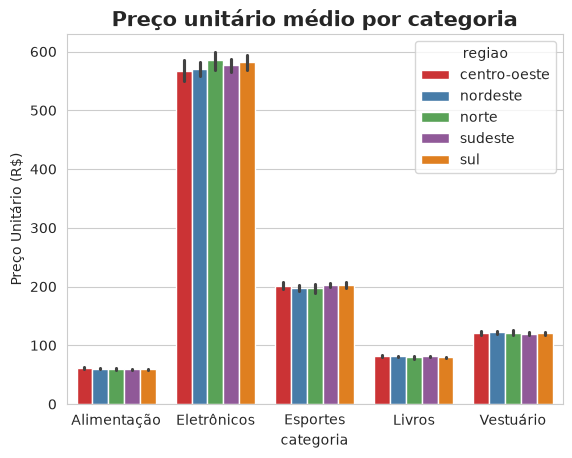

In [ ]:
data = df[~df['flag_outlier_preco']].sort_values(['regiao', 'categoria'])

barras = sns.barplot(data, x='categoria', y='preco_unitario', estimator ='mean', hue='regiao')
barras.set_title('Preço unitário médio por categoria', fontdict={'size': 15, 'weight': 'bold'})
barras.set_ylabel('Preço Unitário (R$)')
barras.set_xlabel('')

Text(0, 0.5, 'Preço Unitário (R$)')

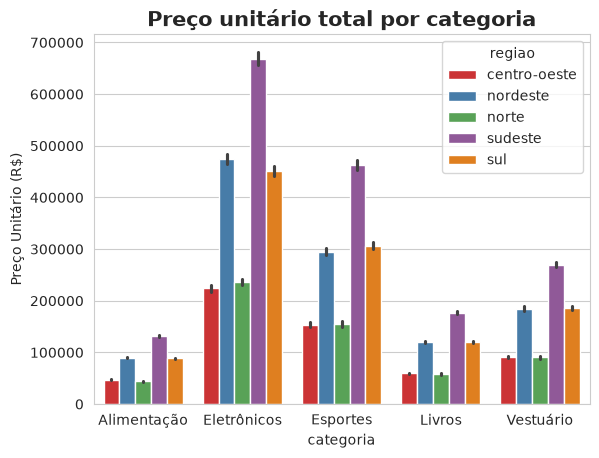

In [ ]:
data = df[~df['flag_outlier_preco']].sort_values(['regiao', 'categoria'])

barras = sns.barplot(data, x='categoria', y='preco_unitario', estimator ='sum', hue='regiao')
barras.set_title('Preço unitário total por categoria', fontdict={'size': 15, 'weight': 'bold'})
barras.set_ylabel('Preço Unitário (R$)')
barras.set_xlabel('')

Text(0, 0.5, 'Quantidade de vendas')

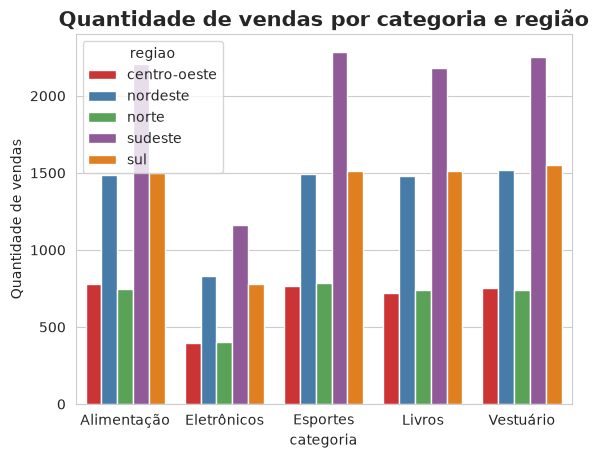

In [ ]:
barras = sns.barplot(data, x='categoria', y='preco_unitario', estimator ='count_nonzero', hue='regiao')
barras.set_title('Quantidade de vendas por categoria e região', fontdict={'size': 15, 'weight': 'bold'})
barras.set_ylabel('Quantidade de vendas')
barras.set_xlabel('')

Podemos observar que os eletrônicos são os produtos mais caros, porém não há muitas compras deles. Da mesma forma, eles apresentam o maior preço total acumulado de todos os tipos. Além disso, podemos ver que o sudeste é a região com mais vendas e dinheiro investido

### B. Gráfico de Linhas

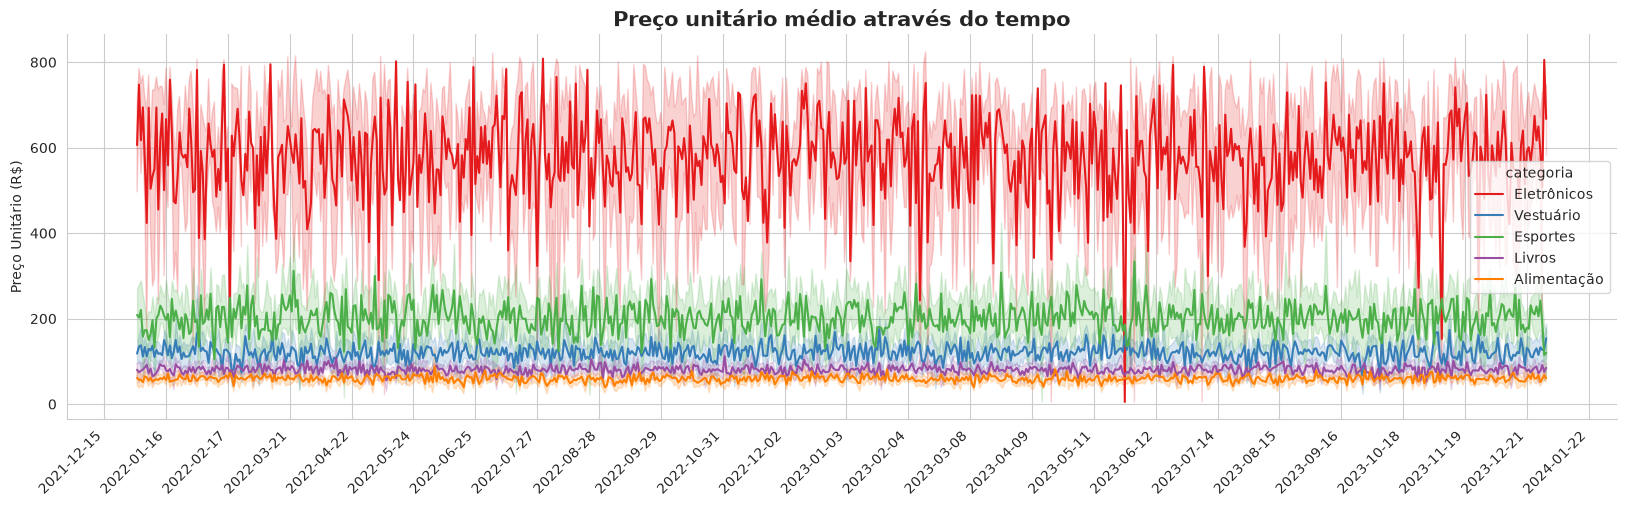

In [136]:
import matplotlib.ticker as ticker

data = df[~df['flag_outlier_preco']]
data.resample("W", on='data_venda')
data.sort_values(['data_venda', 'categoria'])

plt.figure(figsize=(20,5))
linhas = sns.lineplot(data, x='data_venda', y='preco_unitario', hue='categoria')

sns.despine()

linhas.set_title('Preço unitário médio através do tempo', fontdict={'size': 15, 'weight': 'bold'})
linhas.set_ylabel('Preço Unitário (R$)')
linhas.set_xlabel('')


ax = linhas.axes
ax.xaxis.set_major_locator(ticker.MultipleLocator(32))
# ax.set_xticklabels(data['data_venda'].dt.strftime("%b/%Y"))

linhas.tick_params('x', rotation=45, labelrotation_mode='xtick')

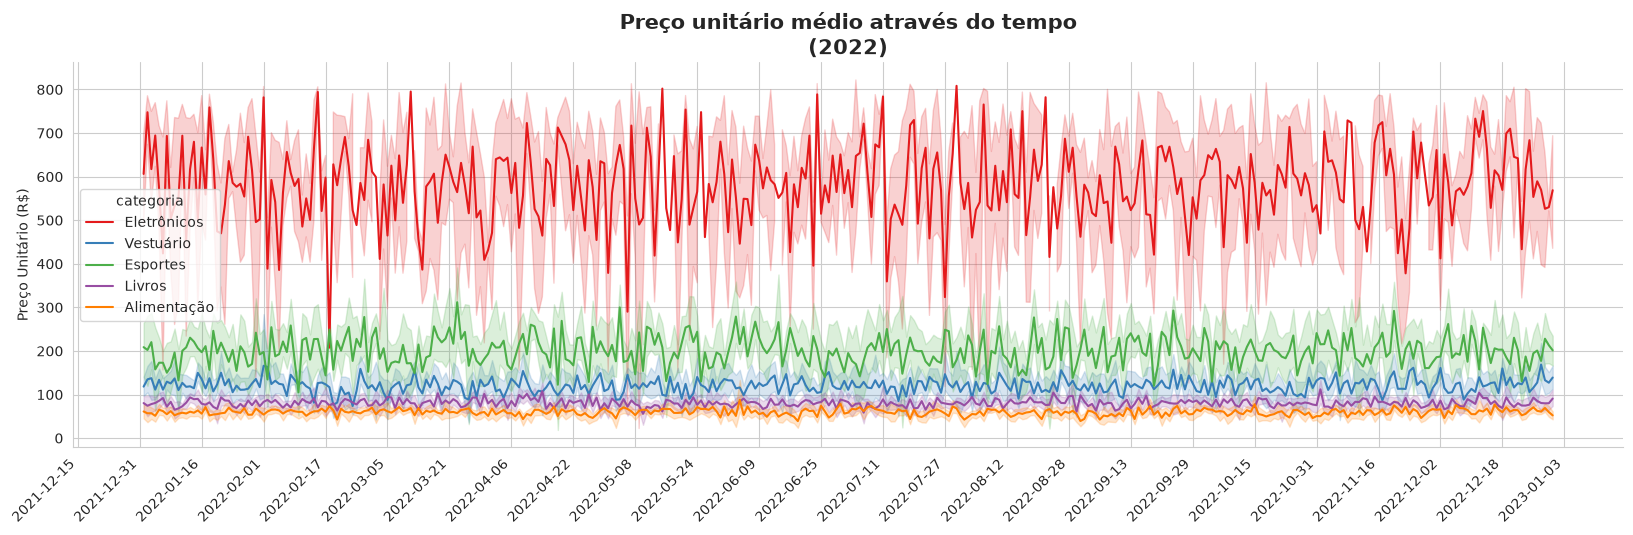

In [140]:
data2 = data[data['data_venda'].dt.year == 2022]
data2.sort_values('categoria')

plt.figure(figsize=(20,5))
linhas = sns.lineplot(data2, x='data_venda', y='preco_unitario', hue='categoria')

sns.despine()

linhas.set_title('Preço unitário médio através do tempo\n(2022)', fontdict={'size': 15, 'weight': 'bold'})
linhas.set_ylabel('Preço Unitário (R$)')
linhas.set_xlabel('')


ax = linhas.axes
ax.xaxis.set_major_locator(ticker.MultipleLocator(16))
# ax.set_xticklabels(data['data_venda'].dt.strftime("%b/%Y"))

linhas.tick_params('x', rotation=45, labelrotation_mode='xtick')


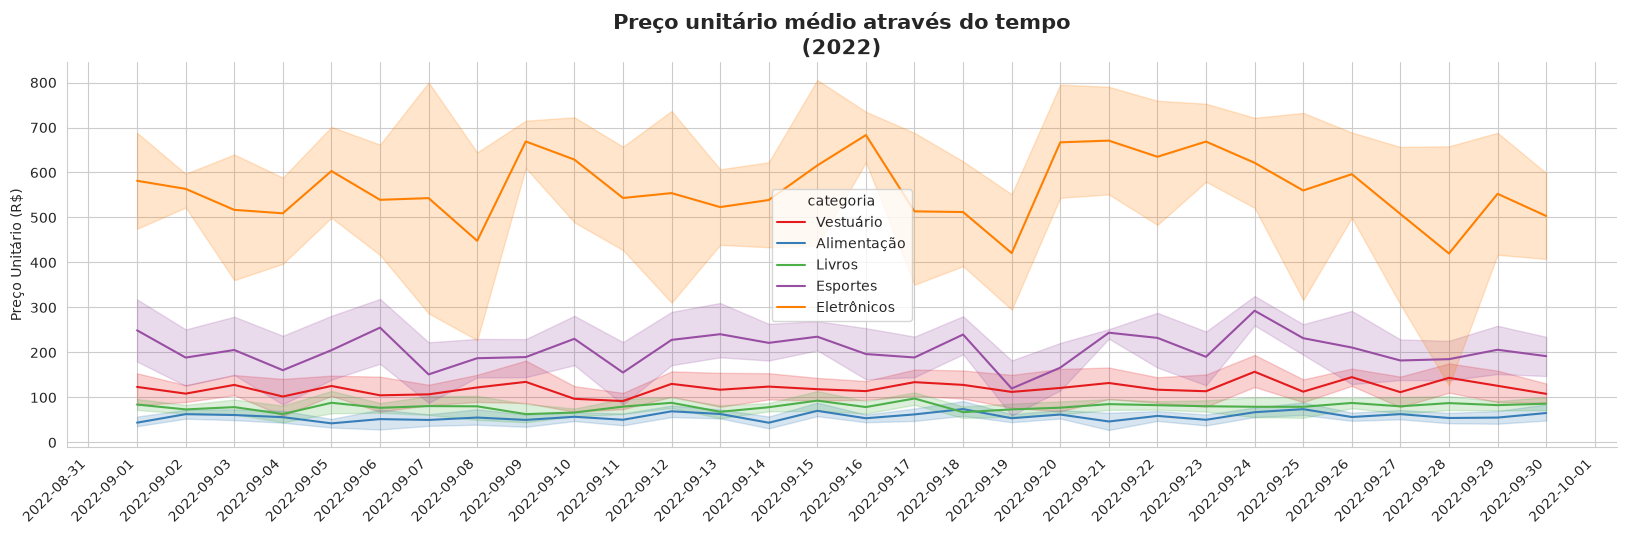

In [141]:
data3 = data2[data2['data_venda'].dt.month == 9]
data3.sort_values('categoria')

plt.figure(figsize=(20,5))
linhas = sns.lineplot(data3, x='data_venda', y='preco_unitario', hue='categoria')

sns.despine()

linhas.set_title('Preço unitário médio através do tempo\n(2022)', fontdict={'size': 15, 'weight': 'bold'})
linhas.set_ylabel('Preço Unitário (R$)')
linhas.set_xlabel('')


ax = linhas.axes
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.set_xticklabels(data['data_venda'].dt.strftime("%b/%Y"))

linhas.tick_params('x', rotation=45, labelrotation_mode='xtick')


Podemos ver que através existe uma certa tendência de ocorrer mais gastos em venda no início e meio do mês. Fora isso, os padrões de sasonalidade não me parecem claros

### C. Gráfico de Dispersão

In [73]:
sorted_df = df.sort_values('categoria')

In [74]:
quantidade_media = sorted_df['quantidade'].mean()
desvio_padrao = sorted_df['quantidade'].std()
sorted_df['quantidade-z-score'] = abs((sorted_df['quantidade'] - quantidade_media)/desvio_padrao)

/tmp/ipykernel_39146/3320289343.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data = sorted_df[~sorted_df['flag_outlier_preco']][sorted_df['quantidade-z-score']<3]


Text(0, 0.5, 'Quantidade')

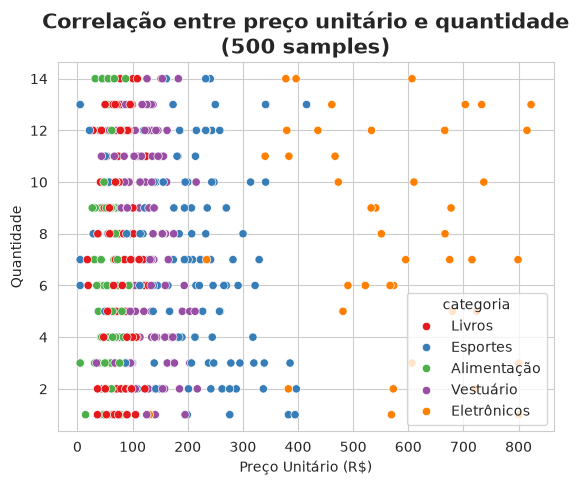

In [75]:
data = sorted_df[~sorted_df['flag_outlier_preco']][sorted_df['quantidade-z-score']<3]
dispersao = sns.scatterplot(data.sample(500), x='preco_unitario', y='quantidade', hue='categoria')

dispersao.set_title('Correlação entre preço unitário e quantidade\n(500 samples)', fontdict={'size': 15, 'weight': 'bold'})
dispersao.set_xlabel('Preço Unitário (R$)')
dispersao.set_ylabel('Quantidade')

Aparentemente, não há relação marcante entre preço unitário e quantidade.

### D. Mapa de Calor

<Axes: >

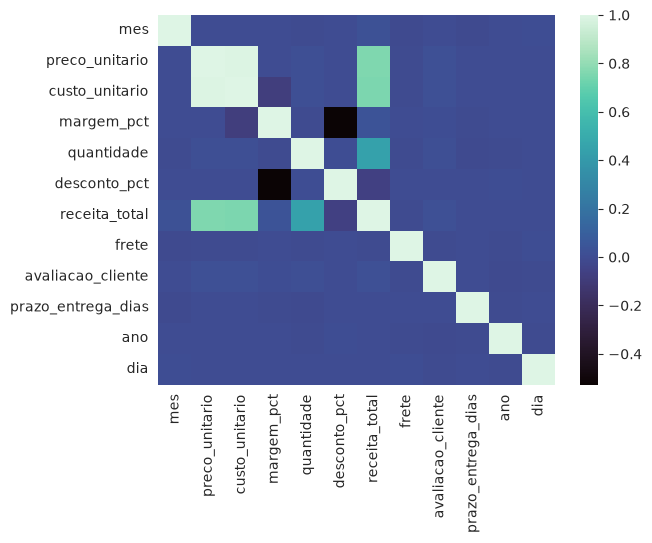

In [76]:
data = df[~df['flag_outlier_preco']].select_dtypes(include=np.number)
sns.heatmap(data.corr(), cmap='mako')

Não temos nenhuma informação surpreendente. Vemos que preço e custo são fortemente e positivamente relacionados, enquanto desconto e margem são inversamente correlatos. Receita está relacionado com preço, custo e quantidade, e o resto é um mar azul de falta de relação. 